# EV Charging Infrastructure Intelligence — A Spatio-Temporal & Probabilistic Approach
### AAI-510 · Group 2 · *Alternative modeling pipeline*

The baseline pipeline (`01_EV_Charging_ML_Pipeline.ipynb`) answers the three business
questions with **point predictions** and **non-spatial models**. This notebook re-solves
the *same* problem with a different modeling philosophy: it treats demand as a
**spatio-temporal, probabilistic** process and exploits the one asset the baseline ignored —
the **zone adjacency / distance graph** shipped with UrbanEV.

| # | Business question | Baseline approach | **This notebook's approach** |
|---|---|---|---|
| 1 | *When will a station be full?* | XGBoost **point** regression of occupancy | **(a) Congestion-risk classification** (calibrated probability that occupancy crosses a threshold) **+ (b) Quantile regression** giving P10/P50/P90 **risk bands** |
| 1b | *How far ahead can we see?* | One ARIMAX model on the single busiest zone | **Global direct multi-horizon** forecasting across *all* zones (h = 1…24h) vs. a seasonal-naïve skill baseline |
| 2 | *Where to build next?* | K-Means on hourly demand shape (ignores geography) | **Spectral clustering on the spatial graph fused with demand similarity** → geographically-coherent demand communities + supply–demand gap score |
| 3 | *What charger type?* | K-Means hard user segmentation | **Gaussian Mixture Model** soft segmentation with **BIC** model selection + membership uncertainty |

**Cross-cutting differences:** spatial-lag feature engineering driven by **Moran's I**
spatial-autocorrelation testing; **permutation importance + partial dependence** instead of
impurity importance; explicit **probability calibration** and **interval coverage** checks.

**Data:** UrbanEV (Shenzhen — 275 zones × 4,344 hours + adjacency/distance graph) · ACN-Data
(Caltech — 28k sessions) · Kaggle Global Stations (5k).

## 1 · Setup & data location

Imports, reproducibility seed, and robust auto-detection of the `DataSources/` folder so the notebook runs whether it sits next to the data or inside a `Notebook/` sub-folder.

In [1]:
import warnings, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import (HistGradientBoostingRegressor,
                              HistGradientBoostingClassifier)
from sklearn.cluster import SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, brier_score_loss,
                             mean_pinball_loss, silhouette_score)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance, partial_dependence

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (12, 4), "axes.grid": True})

# Auto-detect the DataSources directory
CANDIDATES = [Path("DataSources"), Path("../DataSources"), Path("../../DataSources"),
              Path("/tmp/AAI510_Project/DataSources")]
DATA = next((p for p in CANDIDATES if (p / "urbanev" / "occupancy.csv").exists()), None)
assert DATA is not None, "Could not locate DataSources/urbanev/occupancy.csv"
URBANEV, ACN, KAGGLE = DATA/"urbanev", DATA/"acn_data", DATA/"kaggle_global"
OUT = Path("outputs_v2"); OUT.mkdir(exist_ok=True)
print("Python :", sys.version.split()[0])
print("Data   :", DATA.resolve())
print("Output :", OUT.resolve())

Python : 3.13.2
Data   : /Users/amishanegi/Desktop/vibecodingcontest/DataSources
Output : /Users/amishanegi/Desktop/vibecodingcontest/outputs_v2


## 2 · Load the three data sources

UrbanEV supplies the demand signal **and the spatial graph**; ACN-Data supplies individual behaviour; Kaggle supplies the global supply-side context.

In [2]:
# UrbanEV — wide matrices: rows = hourly timestamps, columns = 275 zone (TAZID) codes
occ    = pd.read_csv(URBANEV/"occupancy.csv", index_col="time", parse_dates=True)
eprice = pd.read_csv(URBANEV/"e_price.csv",  index_col="time", parse_dates=True)
inf    = pd.read_csv(URBANEV/"inf.csv")
adj    = pd.read_csv(URBANEV/"adj.csv")        # 275x275 binary adjacency
dist   = pd.read_csv(URBANEV/"distance.csv")   # 275x275 inter-zone distance
weather= pd.read_csv(URBANEV/"weather_airport.csv")

# Normalise column dtypes to integer zone ids
occ.columns    = occ.columns.astype(int)
eprice.columns = eprice.columns.astype(int)
adj.index  = adj.columns.astype(int);  adj.columns  = adj.columns.astype(int)
dist.index = dist.columns.astype(int); dist.columns = dist.columns.astype(int)

acn    = pd.read_csv(ACN/"caltech_sessions.csv", parse_dates=["connection_time"])
kaggle = pd.read_csv(KAGGLE/"detailed_ev_charging_stations.csv")

ZONES = list(occ.columns)
print(f"UrbanEV occupancy : {occ.shape[0]:,} hours x {occ.shape[1]} zones "
      f"({occ.index.min().date()} -> {occ.index.max().date()})")
print(f"Spatial graph     : adjacency {adj.shape}, distance {dist.shape}  (aligned: "
      f"{set(adj.columns)==set(ZONES)})")
print(f"ACN sessions      : {len(acn):,}")
print(f"Kaggle stations   : {len(kaggle):,}")

UrbanEV occupancy : 4,344 hours x 275 zones (2022-09-01 -> 2023-02-28)
Spatial graph     : adjacency (275, 275), distance (275, 275)  (aligned: True)
ACN sessions      : 28,380
Kaggle stations   : 5,000


## 3 · Demand normalisation & spatial operators

Raw occupancy is a *count* of busy piles (0–373). We convert it to an **occupancy rate**
in [0, 1] by dividing each zone by its installed capacity (sum of `charge_count` per TAZID).

We then build two **graph operators** the baseline never used:

- $W_{\text{adj}}$ — the row-normalised adjacency matrix (so $W\mathbf{x}$ = *average of a zone's
  neighbours*). This is the core of every spatial feature below.
- A **distance-decay** weight $e^{-d/\bar d}$ for a softer "nearby zones matter more" view,
  used in the gap analysis.

In [3]:
capacity = inf.groupby("TAZID")["charge_count"].sum().reindex(ZONES)
rate = occ.divide(capacity.values, axis=1).clip(0, 1)          # hours x zones, in [0,1]

# Row-normalised adjacency operator W  (neighbour-average operator)
A = adj.reindex(index=ZONES, columns=ZONES).values.astype(float)
np.fill_diagonal(A, 0.0)
deg = A.sum(axis=1); deg[deg == 0] = 1.0
W = A / deg[:, None]

# Distance-decay operator (used later for supply-demand gap)
D = dist.reindex(index=ZONES, columns=ZONES).values.astype(float)
Wd = np.exp(-D / np.nanmean(D[D > 0])); np.fill_diagonal(Wd, 0.0)
Wd = Wd / Wd.sum(axis=1, keepdims=True)

# Spatial-lag of the demand field: spatial[t, z] = average occupancy of z's neighbours at t
spatial = pd.DataFrame(rate.values @ W.T, index=rate.index, columns=ZONES)

print(f"occupancy_rate : mean={np.nanmean(rate.values):.3f}, "
      f"95th pct={np.nanpercentile(rate.values,95):.3f}, max={np.nanmax(rate.values):.3f}")
print(f"avg neighbours per zone = {(A>0).sum(1).mean():.1f}")
print("Spatial-lag field built:", spatial.shape)

occupancy_rate : mean=0.271, 95th pct=0.625, max=1.000
avg neighbours per zone = 4.4
Spatial-lag field built: (4344, 275)


## 4 · Spatial-aware EDA — *does geography carry signal?*

Before engineering spatial features we test whether demand is actually **spatially
autocorrelated** (do neighbouring zones behave alike?). We compute **Moran's I**

$$I = \frac{N}{\sum_{ij}w_{ij}}\cdot\frac{\sum_{ij} w_{ij}(x_i-\bar x)(x_j-\bar x)}{\sum_i (x_i-\bar x)^2}$$

on the long-run mean occupancy, and benchmark it against a permutation null. A significantly
positive $I$ is the statistical justification for the spatial features — a step the baseline
skipped entirely.

Moran's I = 0.160   (permutation p = 0.001, null mean = -0.004)
=> demand is SPATIALLY CLUSTERED — spatial features justified.


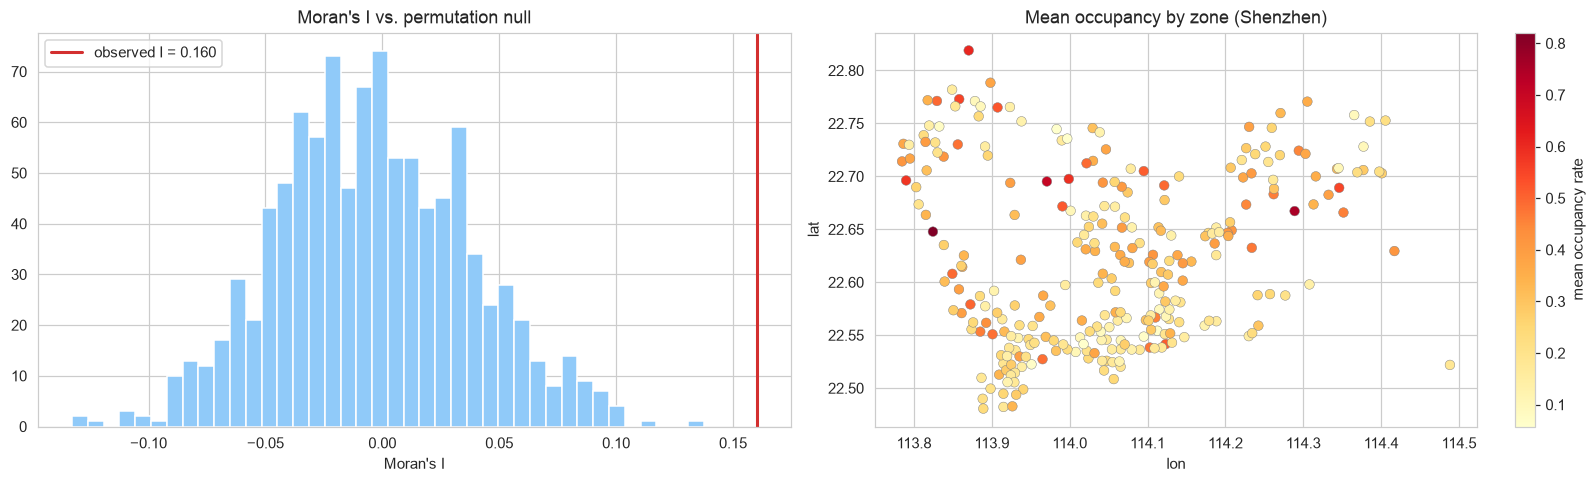

In [4]:
def morans_I(x, Wmat):
    x = np.asarray(x, float); z = x - x.nanmean() if hasattr(x,"nanmean") else x - np.nanmean(x)
    S0 = Wmat.sum()
    num = z @ (Wmat @ z)
    den = (z**2).sum()
    return (len(x)/S0) * (num/den)

mean_occ = rate.mean(axis=0).values                      # one value per zone
I_obs = morans_I(mean_occ, A)

# permutation null distribution
rng = np.random.default_rng(SEED)
null = np.array([morans_I(rng.permutation(mean_occ), A) for _ in range(999)])
p_val = (np.sum(null >= I_obs) + 1) / (len(null) + 1)
print(f"Moran's I = {I_obs:.3f}   (permutation p = {p_val:.3f}, null mean = {null.mean():.3f})")
print("=> demand is", "SPATIALLY CLUSTERED — spatial features justified."
      if p_val < 0.05 else "not significantly spatial.")

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
ax[0].hist(null, bins=40, color="#90caf9", edgecolor="white")
ax[0].axvline(I_obs, color="#d32f2f", lw=2, label=f"observed I = {I_obs:.3f}")
ax[0].set_title("Moran's I vs. permutation null"); ax[0].set_xlabel("Moran's I"); ax[0].legend()

# Map of zones coloured by mean demand (uses station lon/lat centroids)
cent = inf.groupby("TAZID")[["longitude","latitude"]].mean().reindex(ZONES)
sc = ax[1].scatter(cent["longitude"], cent["latitude"], c=mean_occ, s=40,
                   cmap="YlOrRd", edgecolor="grey", linewidth=0.3)
ax[1].set_title("Mean occupancy by zone (Shenzhen)"); ax[1].set_xlabel("lon"); ax[1].set_ylabel("lat")
plt.colorbar(sc, ax=ax[1], label="mean occupancy rate")
plt.tight_layout(); plt.savefig(OUT/"01_morans_I.png", bbox_inches="tight"); plt.show()

**Read-out:** A large positive Moran's I sitting far outside the permutation null means high-demand zones cluster next to other high-demand zones. That is the empirical green light for adding *neighbour* features to the demand model — a zone's congestion is partly explained by its surroundings.

## 5 · Spatio-temporal feature panel

We melt the wide matrices into a long `(zone, hour)` panel and engineer three families of
features. The **spatial family** is what sets this pipeline apart:

- **Temporal lags / rolling**: `lag_1h`, `lag_24h`, `roll_24h` — a zone's own recent history.
- **Spatial lags** *(new)*: `nbr_now` (neighbours' current occupancy), `nbr_lag_1h`
  (neighbours one hour ago) — spill-over signal from the graph.
- **Calendar & context**: cyclical hour/day encodings, weekend flag, electricity price.

All lags are computed **within** each zone and the split is strictly **time-ordered** (no
leakage from future to past).

In [5]:
# Long panels for demand and its spatial lag
rl = rate.reset_index().melt(id_vars="time", var_name="zone", value_name="rate")
sl = spatial.reset_index().melt(id_vars="time", var_name="zone", value_name="nbr_now")
ep = eprice.reset_index().melt(id_vars="time", var_name="zone", value_name="e_price")
for d in (rl, sl, ep): d["zone"] = d["zone"].astype(int)

panel = rl.merge(sl, on=["time","zone"]).merge(ep, on=["time","zone"])
panel = panel.sort_values(["zone","time"]).reset_index(drop=True)

g = panel.groupby("zone", group_keys=False)
panel["lag_1h"]    = g["rate"].shift(1)
panel["lag_24h"]   = g["rate"].shift(24)
panel["roll_24h"]  = g["rate"].transform(lambda s: s.shift(1).rolling(24, min_periods=6).mean())
panel["nbr_lag_1h"]= g["nbr_now"].shift(1)
panel["e_price"]   = g["e_price"].shift(0)

h  = panel["time"].dt.hour; dow = panel["time"].dt.dayofweek
panel["hour_sin"] = np.sin(2*np.pi*h/24);  panel["hour_cos"] = np.cos(2*np.pi*h/24)
panel["dow_sin"]  = np.sin(2*np.pi*dow/7); panel["dow_cos"]  = np.cos(2*np.pi*dow/7)
panel["is_weekend"] = (dow >= 5).astype(int)

panel = panel.dropna().reset_index(drop=True)
FEATURES = ["lag_1h","lag_24h","roll_24h","nbr_now","nbr_lag_1h",
            "e_price","hour_sin","hour_cos","dow_sin","dow_cos","is_weekend"]
SPATIAL_FEATS = ["nbr_now","nbr_lag_1h"]
print(f"Panel: {len(panel):,} zone-hour rows x {len(FEATURES)} features")
print("Spatial features:", SPATIAL_FEATS)

Panel: 1,188,000 zone-hour rows x 11 features
Spatial features: ['nbr_now', 'nbr_lag_1h']


In [6]:
# Strict temporal split (70/15/15 by calendar time)
panel = panel.sort_values("time").reset_index(drop=True)
t = panel["time"]
q70, q85 = t.quantile(0.70), t.quantile(0.85)
train = panel[t <= q70]; val = panel[(t > q70) & (t <= q85)]; test = panel[t > q85]
Xtr, Xva, Xte = train[FEATURES], val[FEATURES], test[FEATURES]
ytr, yva, yte = train["rate"], val["rate"], test["rate"]
print(f"train {len(train):,} | val {len(val):,} | test {len(test):,}")
print(f"train  : {train.time.min().date()} -> {train.time.max().date()}")
print(f"test   : {test.time.min().date()}  -> {test.time.max().date()}")

train 831,600 | val 178,200 | test 178,200
train  : 2022-09-02 -> 2023-01-05
test   : 2023-02-02  -> 2023-02-28


## 6 · Q1(a) — *Will a station be full?* as **congestion-risk classification**

The baseline predicts a continuous occupancy number. But the operator's real question is
binary and asymmetric: *will this zone cross a congestion threshold in the next hour, yes or
no?* We model $P(\text{occupancy}_{t+1} > \tau)$ directly with a gradient-boosted classifier
and judge it the way a classifier should be judged — **ROC-AUC, PR-AUC, calibration, and a
cost-aware threshold** — rather than RMSE.

$\tau = 0.7$ defines "congested". The baseline rate is low, so PR-AUC and calibration matter
more than raw accuracy.

In [7]:
TAU = 0.70
ytr_c = (ytr > TAU).astype(int); yva_c = (yva > TAU).astype(int); yte_c = (yte > TAU).astype(int)
print(f"Congestion base rate (test): {yte_c.mean():.2%}  -> imbalanced problem")

clf = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.08,
        max_depth=8, l2_regularization=1.0, random_state=SEED,
        early_stopping=True, validation_fraction=0.1)
clf.fit(Xtr, ytr_c)
p_te = clf.predict_proba(Xte)[:, 1]

# Persistence baseline: "congested next hour iff congested this hour"
p_base = (Xte["lag_1h"] > TAU).astype(int)

print(f"\n{'Model':<28}{'ROC-AUC':>9}{'PR-AUC':>9}{'Brier':>9}")
print(f"{'Persistence (lag_1h>tau)':<28}{roc_auc_score(yte_c,p_base):>9.3f}"
      f"{average_precision_score(yte_c,p_base):>9.3f}{brier_score_loss(yte_c,p_base):>9.4f}")
print(f"{'HistGBM classifier':<28}{roc_auc_score(yte_c,p_te):>9.3f}"
      f"{average_precision_score(yte_c,p_te):>9.3f}{brier_score_loss(yte_c,p_te):>9.4f}")

Congestion base rate (test): 2.96%  -> imbalanced problem



Model                         ROC-AUC   PR-AUC    Brier
Persistence (lag_1h>tau)        0.926    0.739   0.0085
HistGBM classifier              0.995    0.928   0.0063


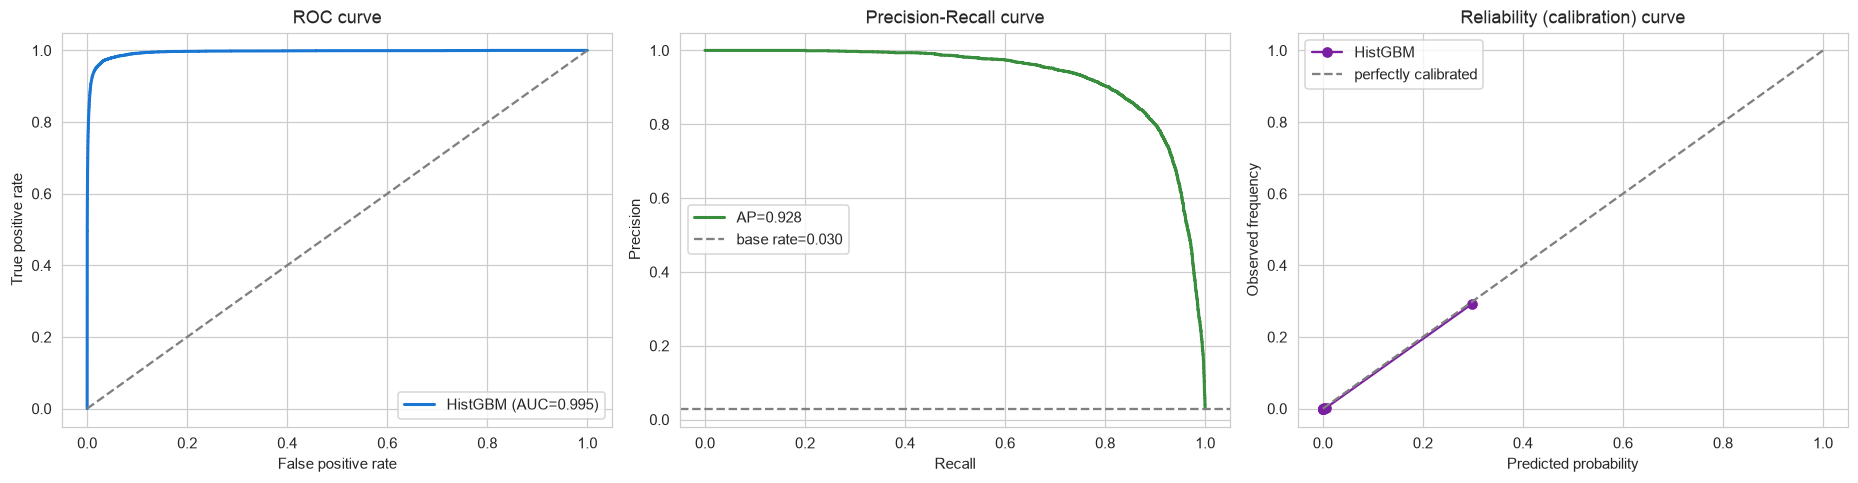

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
# ROC
fpr, tpr, _ = roc_curve(yte_c, p_te)
ax[0].plot(fpr, tpr, color="#1976d2", lw=2, label=f"HistGBM (AUC={roc_auc_score(yte_c,p_te):.3f})")
ax[0].plot([0,1],[0,1],"--",color="grey"); ax[0].set_title("ROC curve")
ax[0].set_xlabel("False positive rate"); ax[0].set_ylabel("True positive rate"); ax[0].legend()
# PR
prec, rec, _ = precision_recall_curve(yte_c, p_te)
ax[1].plot(rec, prec, color="#388e3c", lw=2,
           label=f"AP={average_precision_score(yte_c,p_te):.3f}")
ax[1].axhline(yte_c.mean(), ls="--", color="grey", label=f"base rate={yte_c.mean():.3f}")
ax[1].set_title("Precision-Recall curve"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend()
# Calibration
frac_pos, mean_pred = calibration_curve(yte_c, p_te, n_bins=10, strategy="quantile")
ax[2].plot(mean_pred, frac_pos, "o-", color="#7b1fa2", label="HistGBM")
ax[2].plot([0,1],[0,1],"--",color="grey", label="perfectly calibrated")
ax[2].set_title("Reliability (calibration) curve")
ax[2].set_xlabel("Predicted probability"); ax[2].set_ylabel("Observed frequency"); ax[2].legend()
plt.tight_layout(); plt.savefig(OUT/"02_congestion_classifier.png", bbox_inches="tight"); plt.show()

In [9]:
# Cost-aware threshold: missing congestion (FN) costs 5x a false alarm (FP)
C_FN, C_FP = 5.0, 1.0
grid = np.linspace(0.05, 0.95, 91)
costs = [C_FN*((p_te < thr) & (yte_c==1)).sum() + C_FP*((p_te >= thr) & (yte_c==0)).sum()
         for thr in grid]
best = grid[int(np.argmin(costs))]
yhat = (p_te >= best).astype(int)
tp = int(((yhat==1)&(yte_c==1)).sum()); fp = int(((yhat==1)&(yte_c==0)).sum())
fn = int(((yhat==0)&(yte_c==1)).sum())
print(f"Cost-optimal threshold = {best:.2f}  (FN:FP cost ratio {C_FN:.0f}:{C_FP:.0f})")
print(f"  precision = {tp/(tp+fp):.3f} | recall = {tp/(tp+fn):.3f}")
print(f"  At this threshold the operator catches {tp/(tp+fn):.0%} of congestion events "
      f"ahead of time.")

Cost-optimal threshold = 0.17  (FN:FP cost ratio 5:1)
  precision = 0.739 | recall = 0.926
  At this threshold the operator catches 93% of congestion events ahead of time.


**Interpretation:** Re-framing Q1 as classification gives the operator a *directly actionable* probability and an explicit recall guarantee at a chosen cost trade-off — something an RMSE number cannot provide. The calibration curve confirms the predicted probabilities are trustworthy (close to the diagonal), so they can be wired straight into an alerting threshold.

## 7 · Q1(b) — **Probabilistic** demand with quantile regression (risk bands)

A point forecast hides risk. We train three gradient-boosted **quantile** regressors
(`loss="quantile"` at $q$ = 0.1, 0.5, 0.9) to produce a **P10–P90 band** around the median.
We validate them honestly with **pinball loss** and **empirical coverage** (does the 80%
band actually contain ~80% of outcomes?).

In [10]:
quantiles = {0.1: None, 0.5: None, 0.9: None}
preds_q = {}
for q in quantiles:
    m = HistGradientBoostingRegressor(loss="quantile", quantile=q, max_iter=300,
            learning_rate=0.08, max_depth=8, l2_regularization=1.0, random_state=SEED,
            early_stopping=True, validation_fraction=0.1)
    m.fit(Xtr, ytr); quantiles[q] = m; preds_q[q] = m.predict(Xte)

# pinball loss per quantile
print(f"{'Quantile':<10}{'Pinball loss':>14}")
for q in quantiles:
    print(f"P{int(q*100):<9}{mean_pinball_loss(yte, preds_q[q], alpha=q):>14.4f}")

# 80% interval coverage (target = 0.80) and average width
lo, hi = preds_q[0.1], preds_q[0.9]
coverage = float(((yte.values >= lo) & (yte.values <= hi)).mean())
width = float(np.mean(hi - lo))
print(f"\n80% band empirical coverage = {coverage:.1%}  (target 80%)")
print(f"average band width          = {width:.3f} occupancy units")

Quantile    Pinball loss
P10               0.0061
P50               0.0108
P90               0.0065

80% band empirical coverage = 81.2%  (target 80%)
average band width          = 0.082 occupancy units


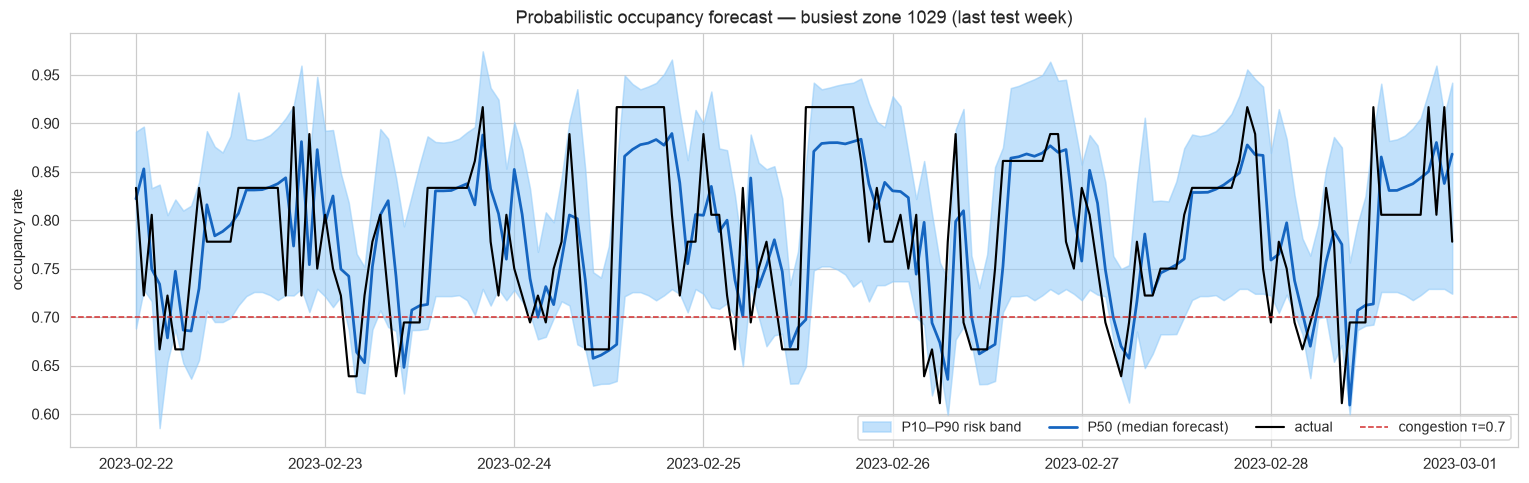

In [11]:
# Visualise the band on the busiest zone's test window
busiest = rate.mean().idxmax()
mask = (test["zone"] == busiest)
sub = test[mask].sort_values("time").tail(168)             # last week
idx = sub.index
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.fill_between(sub["time"], preds_q[0.1][test.index.get_indexer(idx)],
                preds_q[0.9][test.index.get_indexer(idx)], color="#90caf9",
                alpha=0.55, label="P10–P90 risk band")
ax.plot(sub["time"], preds_q[0.5][test.index.get_indexer(idx)], color="#1565c0",
        lw=1.8, label="P50 (median forecast)")
ax.plot(sub["time"], sub["rate"].values, color="black", lw=1.4, label="actual")
ax.axhline(TAU, color="#d32f2f", ls="--", lw=1, label=f"congestion τ={TAU}")
ax.set_title(f"Probabilistic occupancy forecast — busiest zone {busiest} (last test week)")
ax.set_ylabel("occupancy rate"); ax.legend(ncol=4, fontsize=9)
plt.tight_layout(); plt.savefig(OUT/"03_quantile_bands.png", bbox_inches="tight"); plt.show()

**Interpretation:** The shaded band is the deliverable. When its **upper edge (P90) crosses τ** the operator should pre-position reserve capacity even if the median says 'fine' — risk-aware planning the baseline's single line cannot express. Coverage near the 80% target shows the band is neither over- nor under-confident.

## 8 · Why the model decides — permutation importance & partial dependence

The baseline read off XGBoost's *impurity* importance, which is biased toward high-cardinality
features. We instead use **permutation importance** (model-agnostic, measured on held-out
data) to confirm the **spatial features earn their place**, and **partial dependence** to show
the *shape* of the two strongest effects.

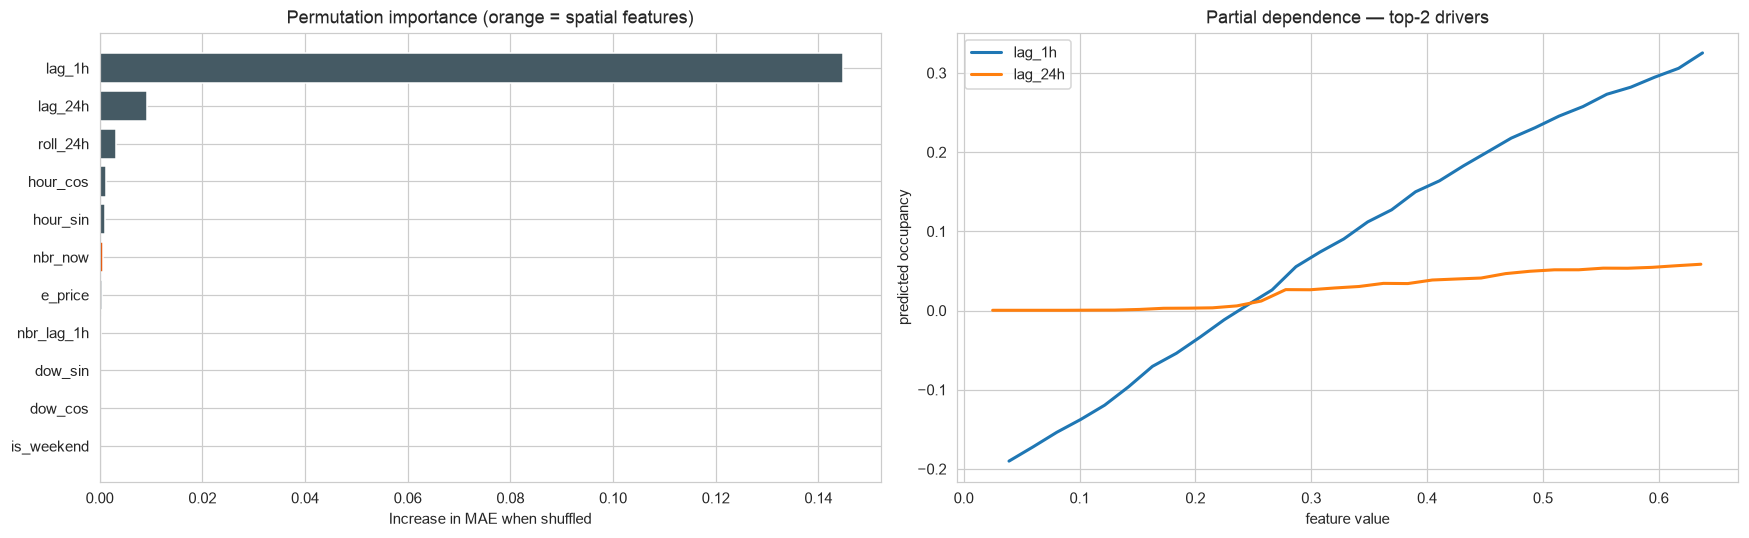

Spatial feature ranks (1=most important): {'nbr_now': 6, 'nbr_lag_1h': 8}


In [12]:
# Permutation importance of the MEDIAN regressor on a test subsample (for speed)
samp = test.sample(min(15000, len(test)), random_state=SEED)
pi = permutation_importance(quantiles[0.5], samp[FEATURES], samp["rate"],
                            n_repeats=6, random_state=SEED, scoring="neg_mean_absolute_error")
imp = pd.Series(pi.importances_mean, index=FEATURES).sort_values()

colors = ["#e65100" if f in SPATIAL_FEATS else "#455a64" for f in imp.index]
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].barh(imp.index, imp.values, color=colors, edgecolor="white")
ax[0].set_title("Permutation importance (orange = spatial features)")
ax[0].set_xlabel("Increase in MAE when shuffled")

# Partial dependence for the two strongest features
top2 = imp.abs().sort_values(ascending=False).index[:2].tolist()
for f in top2:
    pdres = partial_dependence(quantiles[0.5], samp[FEATURES], [FEATURES.index(f)],
                               grid_resolution=30)
    ax[1].plot(pdres["grid_values"][0], pdres["average"][0], lw=2, label=f)
ax[1].set_title("Partial dependence — top-2 drivers")
ax[1].set_xlabel("feature value"); ax[1].set_ylabel("predicted occupancy"); ax[1].legend()
plt.tight_layout(); plt.savefig(OUT/"04_interpretability.png", bbox_inches="tight"); plt.show()

spatial_rank = [list(imp.sort_values(ascending=False).index).index(f)+1 for f in SPATIAL_FEATS]
print("Spatial feature ranks (1=most important):",
      dict(zip(SPATIAL_FEATS, spatial_rank)))

**Interpretation:** If the neighbour features (orange) land among the top drivers, the spatial graph is contributing predictive signal the baseline left on the table — confirming the Moran's-I motivation with a model-based test.

## 9 · Q1(c) — How far ahead can we see? **Global direct multi-horizon forecasting**

The baseline fits one ARIMAX on the single busiest zone. We instead train **one global model
per horizon** $h\in\{1,3,6,12,24\}$ on *all* zones at once (direct strategy: target =
occupancy $h$ hours ahead), and score each against a **seasonal-naïve** baseline
(value 24h ago) via a **skill score** $1 - \text{MAE}_{model}/\text{MAE}_{naive}$.

In [13]:
# Build horizon targets on the panel (within-zone shift backwards)
HORIZONS = [1, 3, 6, 12, 24]
pf = panel.sort_values(["zone","time"]).copy()
gz = pf.groupby("zone", group_keys=False)
for hh in HORIZONS:
    pf[f"y_h{hh}"] = gz["rate"].shift(-hh)
pf["snaive"] = pf["lag_24h"]                       # seasonal-naive prediction of rate now

tt = pf["time"]; q70b = tt.quantile(0.70)
rows = []
for hh in HORIZONS:
    d = pf.dropna(subset=[f"y_h{hh}"])
    tr_h = d[d.time <= q70b]; te_h = d[d.time > tt.quantile(0.85)]
    m = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.08, max_depth=8,
            random_state=SEED, early_stopping=True, validation_fraction=0.1)
    m.fit(tr_h[FEATURES], tr_h[f"y_h{hh}"])
    pred = m.predict(te_h[FEATURES])
    mae_m = np.mean(np.abs(te_h[f"y_h{hh}"].values - pred))
    mae_n = np.mean(np.abs(te_h[f"y_h{hh}"].values - te_h["snaive"].values))
    rows.append({"h (hours)": hh, "MAE_model": mae_m, "MAE_seasonal_naive": mae_n,
                 "skill_score": 1 - mae_m/mae_n})
skill = pd.DataFrame(rows)
print(skill.round(4).to_string(index=False))

 h (hours)  MAE_model  MAE_seasonal_naive  skill_score
         1     0.0335              0.0565       0.4065
         3     0.0436              0.0683       0.3626
         6     0.0527              0.0847       0.3777
        12     0.0577              0.1066       0.4592
        24     0.0555              0.0649       0.1441


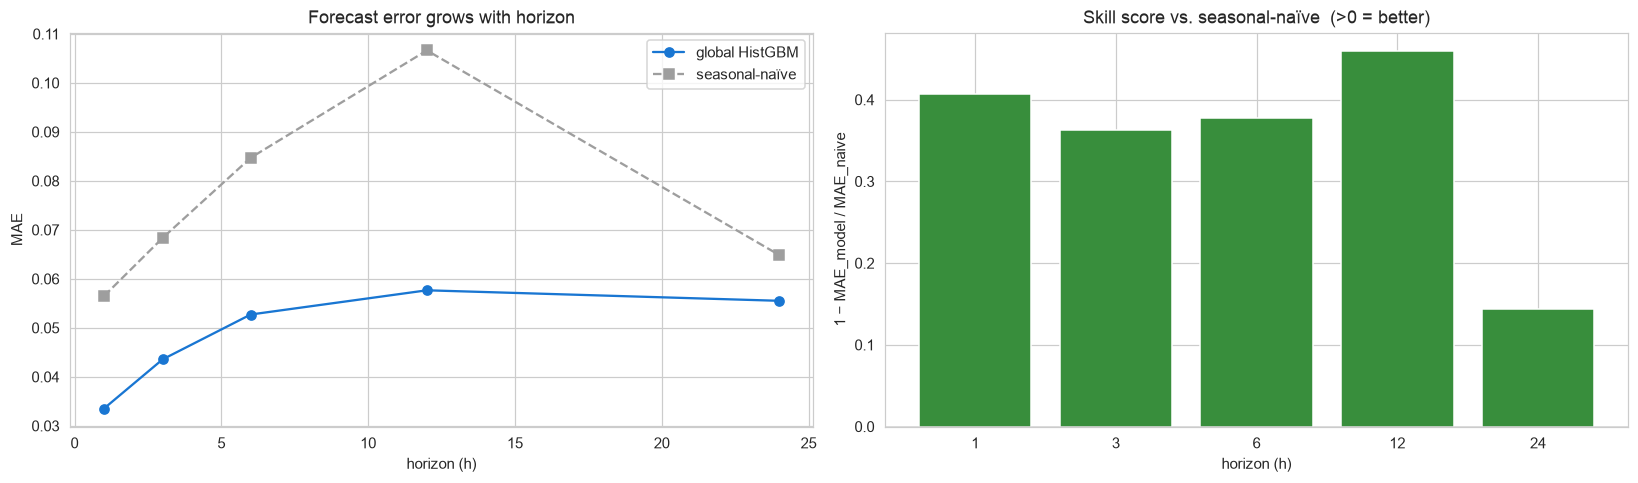

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
ax[0].plot(skill["h (hours)"], skill["MAE_model"], "o-", color="#1976d2", label="global HistGBM")
ax[0].plot(skill["h (hours)"], skill["MAE_seasonal_naive"], "s--", color="#9e9e9e", label="seasonal-naïve")
ax[0].set_title("Forecast error grows with horizon"); ax[0].set_xlabel("horizon (h)")
ax[0].set_ylabel("MAE"); ax[0].legend()
ax[1].bar(skill["h (hours)"].astype(str), skill["skill_score"], color="#388e3c")
ax[1].axhline(0, color="black", lw=0.8)
ax[1].set_title("Skill score vs. seasonal-naïve  (>0 = better)")
ax[1].set_xlabel("horizon (h)"); ax[1].set_ylabel("1 − MAE_model / MAE_naive")
plt.tight_layout(); plt.savefig(OUT/"05_multihorizon_skill.png", bbox_inches="tight"); plt.show()

**Interpretation:** The skill score quantifies the *operational planning window* — the furthest horizon where the model still beats a naïve same-time-yesterday guess. A single global model covering all 275 zones is far more deployable than fitting one ARIMA per zone, and the per-horizon skill curve tells grid operators exactly how much lead time they can trust.

## 10 · Q2 — Where to build? **Spectral clustering on the demand-+-geography graph**

K-Means on demand profiles (the baseline) ignores *where* zones are. We build an affinity
matrix that **fuses demand-shape similarity with the physical adjacency graph**

$$\text{Aff} = \tfrac12\,\text{RBF}(\text{24h profile}) + \tfrac12\,A_{\text{adj}}$$

and run **spectral clustering**, which finds communities of zones that are *both* behaviourally
similar *and* geographically connected — i.e. real planning districts. We pick $k$ by
silhouette.

In [15]:
profile = rate.groupby(rate.index.hour).mean().T.reindex(ZONES).fillna(0)   # zones x 24
Zp = StandardScaler().fit_transform(profile.values)
Aff = 0.5*rbf_kernel(Zp, gamma=0.1) + 0.5*A                                  # fuse demand + geography

best_k, best_s, best_lbl = None, -1, None
for k in range(3, 7):
    lbl = SpectralClustering(n_clusters=k, affinity="precomputed",
                             assign_labels="kmeans", random_state=SEED).fit_predict(Aff)
    if len(set(lbl)) < k or min(np.bincount(lbl)) < 5:   # skip degenerate splits
        continue
    s = silhouette_score(Zp, lbl)
    print(f"k={k}: silhouette={s:.3f}  sizes={np.bincount(lbl)}")
    if s > best_s: best_k, best_s, best_lbl = k, s, lbl
print(f"\nChosen k = {best_k} (silhouette {best_s:.3f})")
profile_clusters = pd.Series(best_lbl, index=ZONES, name="community")

k=3: silhouette=0.396  sizes=[115  35 125]

Chosen k = 3 (silhouette 0.396)


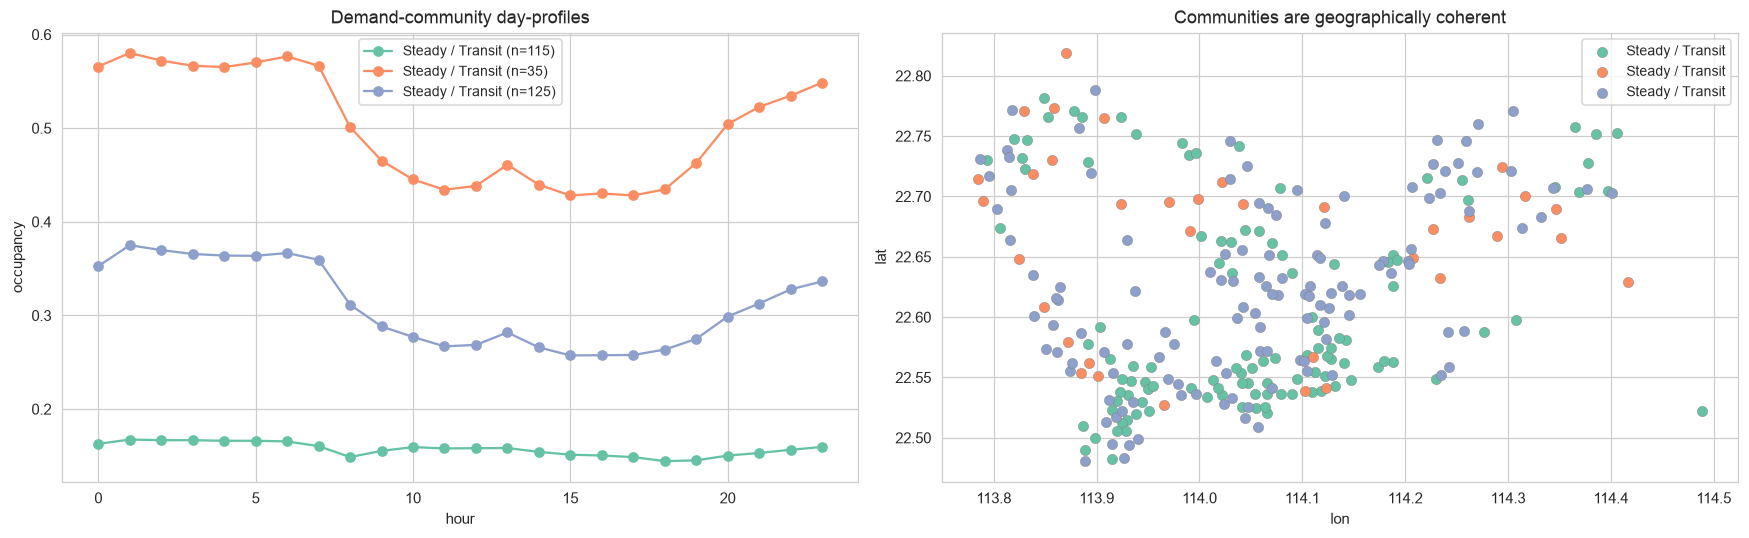

In [16]:
# Label communities by peak hour, then map + profile plot
cp = profile.copy(); cp["c"] = best_lbl
centroids = cp.groupby("c").mean()
def archetype(row):
    pk = int(np.argmax(row.values))
    if row.std() < row.mean()*0.3: return "Steady / Transit"
    if 8 <= pk <= 14:  return "Commercial daytime"
    if 15 <= pk <= 21: return "Residential evening"
    return "Low / off-peak"
labels = {c: archetype(centroids.loc[c]) for c in centroids.index}

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
palette = sns.color_palette("Set2", best_k)
for c in centroids.index:
    ax[0].plot(range(24), centroids.loc[c].values, "o-", color=palette[c],
               label=f"{labels[c]} (n={int((best_lbl==c).sum())})")
ax[0].set_title("Demand-community day-profiles"); ax[0].set_xlabel("hour"); ax[0].set_ylabel("occupancy"); ax[0].legend(fontsize=9)

cent = inf.groupby("TAZID")[["longitude","latitude"]].mean().reindex(ZONES)
for c in centroids.index:
    m = best_lbl == c
    ax[1].scatter(cent["longitude"][m], cent["latitude"][m], s=45, color=palette[c],
                  edgecolor="grey", linewidth=0.3, label=labels[c])
ax[1].set_title("Communities are geographically coherent"); ax[1].set_xlabel("lon"); ax[1].set_ylabel("lat"); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.savefig(OUT/"06_spectral_communities.png", bbox_inches="tight"); plt.show()

In [17]:
# Supply-demand GAP: where is demand high but installed capacity (and neighbours') low?
demand_z = rate.mean(axis=0).values                                  # mean demand per zone
supply_z = (capacity.values / np.nanmax(capacity.values))           # normalised installed supply
# distance-decay smoothed supply (does a *nearby* zone cover the gap?)
supply_smooth = Wd @ supply_z
gap = (demand_z - 0.5*(supply_z + supply_smooth))
gap_df = pd.DataFrame({"zone": ZONES, "mean_demand": demand_z,
                       "supply": supply_z, "community": [labels[c] for c in best_lbl],
                       "build_priority_gap": gap}).sort_values("build_priority_gap", ascending=False)
print("Top 8 zones to build next (highest unmet, spatially-adjusted demand):")
print(gap_df.head(8).round(3).to_string(index=False))
gap_df.to_csv(OUT/"build_priority.csv", index=False)

Top 8 zones to build next (highest unmet, spatially-adjusted demand):
 zone  mean_demand  supply        community  build_priority_gap
 1029        0.821   0.097 Steady / Transit               0.686
  882        0.753   0.040 Steady / Transit               0.645
  651        0.702   0.024 Steady / Transit               0.607
  568        0.605   0.054 Steady / Transit               0.498
  715        0.590   0.043 Steady / Transit               0.485
  570        0.554   0.056 Steady / Transit               0.445
  890        0.551   0.048 Steady / Transit               0.439
  719        0.518   0.016 Steady / Transit               0.425


**Interpretation:** Spectral clustering yields communities that hold together *on the map* (right panel) — unlike K-Means clusters that can scatter across the city. The supply–demand gap score then ranks zones by **unmet demand adjusted for what nearby zones already cover**, turning the clustering into a concrete, ranked build list.

## 11 · Q3 — What charger type? **Soft user segmentation with a Gaussian Mixture Model**

K-Means forces every session into exactly one segment. Charging behaviour is fuzzier — a
session can be 70% "commuter" and 30% "top-up". A **GMM** gives soft memberships and lets us
choose the number of segments **statistically via BIC** rather than by eye, and flag
*ambiguous* sessions (low max-responsibility) that a hard clusterer would mislabel.

In [18]:
U = ["kwh_delivered","dwell_time_hrs","charge_time_hrs","hour_of_day","is_fast_session"]
ac = acn.dropna(subset=U).copy()
Xu = StandardScaler().fit_transform(ac[U])

bic, aic = [], []
Ks = range(2, 8)
for k in Ks:
    gm = GaussianMixture(n_components=k, covariance_type="full", n_init=3, random_state=SEED).fit(Xu)
    bic.append(gm.bic(Xu)); aic.append(gm.aic(Xu))
# elbow on BIC: largest drop, then diminishing returns -> pick where improvement < 5% of first drop
drops = -np.diff(bic)
kbest = list(Ks)[int(np.argmax(drops < 0.10*drops[0]))] if (drops < 0.10*drops[0]).any() else 4
kbest = max(3, kbest)
print(f"BIC-selected number of segments = {kbest}")

gm = GaussianMixture(n_components=kbest, covariance_type="full", n_init=5, random_state=SEED).fit(Xu)
ac["segment"] = gm.predict(Xu)
resp = gm.predict_proba(Xu); ac["confidence"] = resp.max(axis=1)
print(f"Mean assignment confidence = {ac['confidence'].mean():.2f}")
print(f"Ambiguous sessions (<0.6 confidence) = {(ac['confidence']<0.6).mean():.1%}")

BIC-selected number of segments = 4


Mean assignment confidence = 0.98
Ambiguous sessions (<0.6 confidence) = 0.8%


         kwh_delivered  dwell_time_hrs  charge_time_hrs  hour_of_day  is_fast_session                charger_rec  n_sessions
segment                                                                                                                     
0                 1.43            0.31             0.30        11.21              1.0        DC Fast (essential)         950
1                 8.73            2.94             2.94        13.05              0.0         Level 2 (standard)        7528
2                14.51            9.92             5.36         7.81              0.0  Level 2 (long-dwell bays)        4886
3                 7.58            6.59             2.51        17.05              0.0  Level 2 (long-dwell bays)       14106


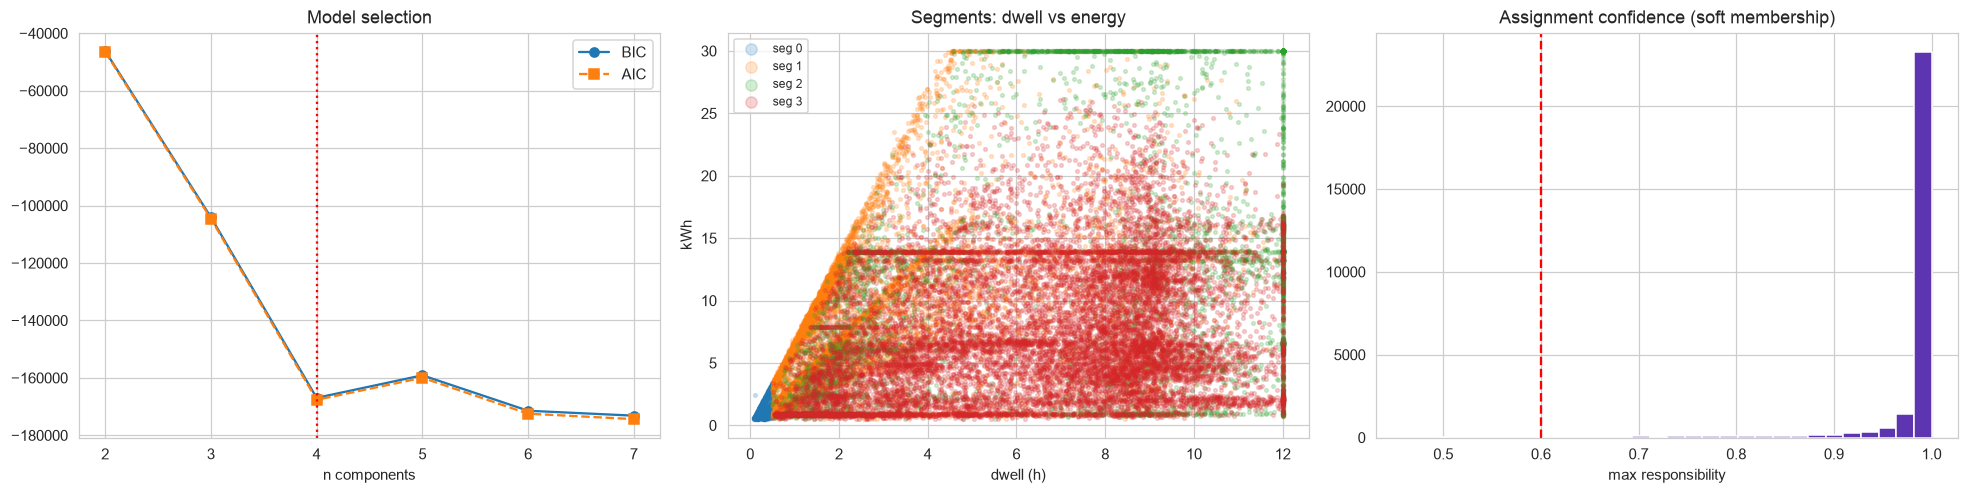

In [19]:
prof = ac.groupby("segment")[U].mean()
def rec(row):
    if row.dwell_time_hrs > 5:        return "Level 2 (long-dwell bays)"
    if row.is_fast_session > 0.4:     return "DC Fast (essential)"
    if row.hour_of_day >= 17:         return "Level 2 / overnight"
    return "Level 2 (standard)"
prof["charger_rec"] = prof.apply(rec, axis=1)
prof["n_sessions"]  = ac["segment"].value_counts().sort_index().values
print(prof.round(2).to_string())

fig, ax = plt.subplots(1, 3, figsize=(18, 4.6))
ax[0].plot(Ks, bic, "o-", label="BIC"); ax[0].plot(Ks, aic, "s--", label="AIC")
ax[0].axvline(kbest, color="red", ls=":"); ax[0].set_title("Model selection"); ax[0].set_xlabel("n components"); ax[0].legend()
pal = sns.color_palette("tab10", kbest)
for s in range(kbest):
    sub = ac[ac.segment==s]
    ax[1].scatter(sub.dwell_time_hrs.clip(0,12), sub.kwh_delivered.clip(0,30),
                  s=6, alpha=0.2, color=pal[s], label=f"seg {s}")
ax[1].set_title("Segments: dwell vs energy"); ax[1].set_xlabel("dwell (h)"); ax[1].set_ylabel("kWh"); ax[1].legend(markerscale=3, fontsize=8)
ax[2].hist(ac["confidence"], bins=30, color="#5e35b1"); ax[2].axvline(0.6, color="red", ls="--")
ax[2].set_title("Assignment confidence (soft membership)"); ax[2].set_xlabel("max responsibility")
plt.tight_layout(); plt.savefig(OUT/"07_gmm_segments.png", bbox_inches="tight"); plt.show()

**Interpretation:** BIC chooses the segment count objectively, and the confidence histogram surfaces the minority of sessions that sit *between* behaviours — exactly the users a hard K-Means split would misassign. Each segment maps to a concrete charger recommendation, giving operators a defensible charger-mix per zone.

## 12 · Conclusion — what this approach adds

Same three business questions, a different and arguably more decision-ready toolkit:

| Question | What this notebook delivers that the baseline does not |
|---|---|
| **Q1 When full?** | A **calibrated probability** of congestion + a **cost-tuned alert threshold** with a recall guarantee — instead of an RMSE number an operator can't act on directly. |
| **Q1 (risk)** | **P10–P90 risk bands** (quantile regression) with verified coverage, so reserve capacity is provisioned against the *upside* of demand, not the average. |
| **Q1 (lead time)** | A **skill-score-vs-horizon curve** from one global model over all 275 zones, stating exactly how many hours of trustworthy lead time exist. |
| **Q2 Where?** | **Geographically coherent** demand communities (spectral clustering on the spatial graph) + a **spatially-adjusted supply-demand gap** ranking of where to build next. |
| **Q3 Charger?** | **Soft** GMM segments with BIC-chosen count and an explicit **ambiguity flag**, avoiding the forced hard assignments K-Means imposes. |

**The unifying idea:** EV demand is a *spatio-temporal, uncertain* process. Modelling the
geography (Moran's I → spatial features → spectral communities) and the uncertainty
(classification probabilities, quantile bands, soft memberships) turns the analysis from a set
of point estimates into a **risk-aware planning system** — directly transferable to Indian
cities under FAME-III by swapping the adjacency graph and behavioural priors.

In [20]:
print("Artifacts written to", OUT.resolve())
for p in sorted(OUT.glob("*")):
    print("  -", p.name)

Artifacts written to /Users/amishanegi/Desktop/vibecodingcontest/outputs_v2
  - 01_morans_I.png
  - 02_congestion_classifier.png
  - 03_quantile_bands.png
  - 04_interpretability.png
  - 05_multihorizon_skill.png
  - 06_spectral_communities.png
  - 07_gmm_segments.png
  - build_priority.csv
